# 🩺 Diabetes Prediction using Machine Learning

This notebook walks through a complete machine learning pipeline to predict whether a patient is diabetic based on clinical measurements. We use the **PIMA Indians Diabetes Dataset** and train a **Support Vector Machine (SVM)** classifier.

### Pipeline Overview
1. Import libraries
2. Load and explore the dataset
3. Visualize key patterns in the data
4. Preprocess and standardize features
5. Train/test split
6. Train the SVM model
7. Evaluate performance
8. Build a live prediction function
9. Save the model

## 1. Import Libraries

We import the core libraries needed for data manipulation, visualization, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load & Explore the Dataset

The **PIMA Indians Diabetes Dataset** contains 768 patient records with 8 clinical features and a binary outcome:
- `0` → Non-Diabetic
- `1` → Diabetic

Let's load it and take a first look.

In [2]:
# Load the dataset
df = pd.read_csv('diabetes.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
# Check for missing values and data types
print('=== Dataset Info ===')
df.info()

print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigre

In [4]:
# Summary statistics
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


In [5]:
# Class distribution
class_counts = df['Outcome'].value_counts()
print('Class Distribution:')
print(f'  Non-Diabetic (0): {class_counts[0]} patients ({class_counts[0]/len(df)*100:.1f}%)')
print(f'  Diabetic     (1): {class_counts[1]} patients ({class_counts[1]/len(df)*100:.1f}%)')

Class Distribution:
  Non-Diabetic (0): 500 patients (65.1%)
  Diabetic     (1): 268 patients (34.9%)


In [6]:
# Mean feature values grouped by outcome
print('Average feature values by diabetes status:')
df.groupby('Outcome').mean().T.style.background_gradient(cmap='RdYlGn', axis=1)

Average feature values by diabetes status:


Outcome,0,1
Pregnancies,3.298000,4.865672
Glucose,109.980000,141.257463
BloodPressure,68.184000,70.824627
SkinThickness,19.664000,22.164179
Insulin,68.792000,100.335821
BMI,30.304200,35.142537
DiabetesPedigreeFunction,0.429734,0.550500
Age,31.190000,37.067164


## 3. Data Visualization

Before modeling, let's explore the data visually to understand distributions, class imbalance, and feature relationships.

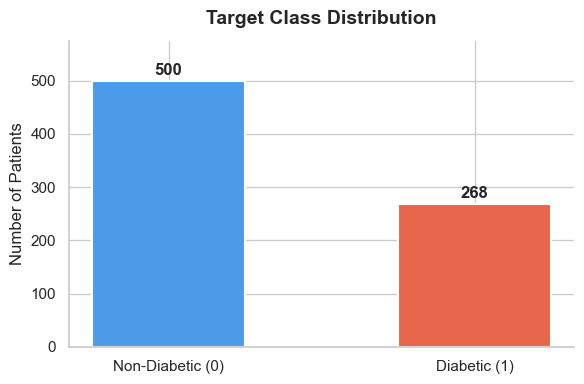

In [7]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Non-Diabetic (0)', 'Diabetic (1)'], class_counts.values,
               color=['#4C9BE8', '#E8664C'], edgecolor='white', linewidth=1.5, width=0.5)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Target Class Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, max(class_counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

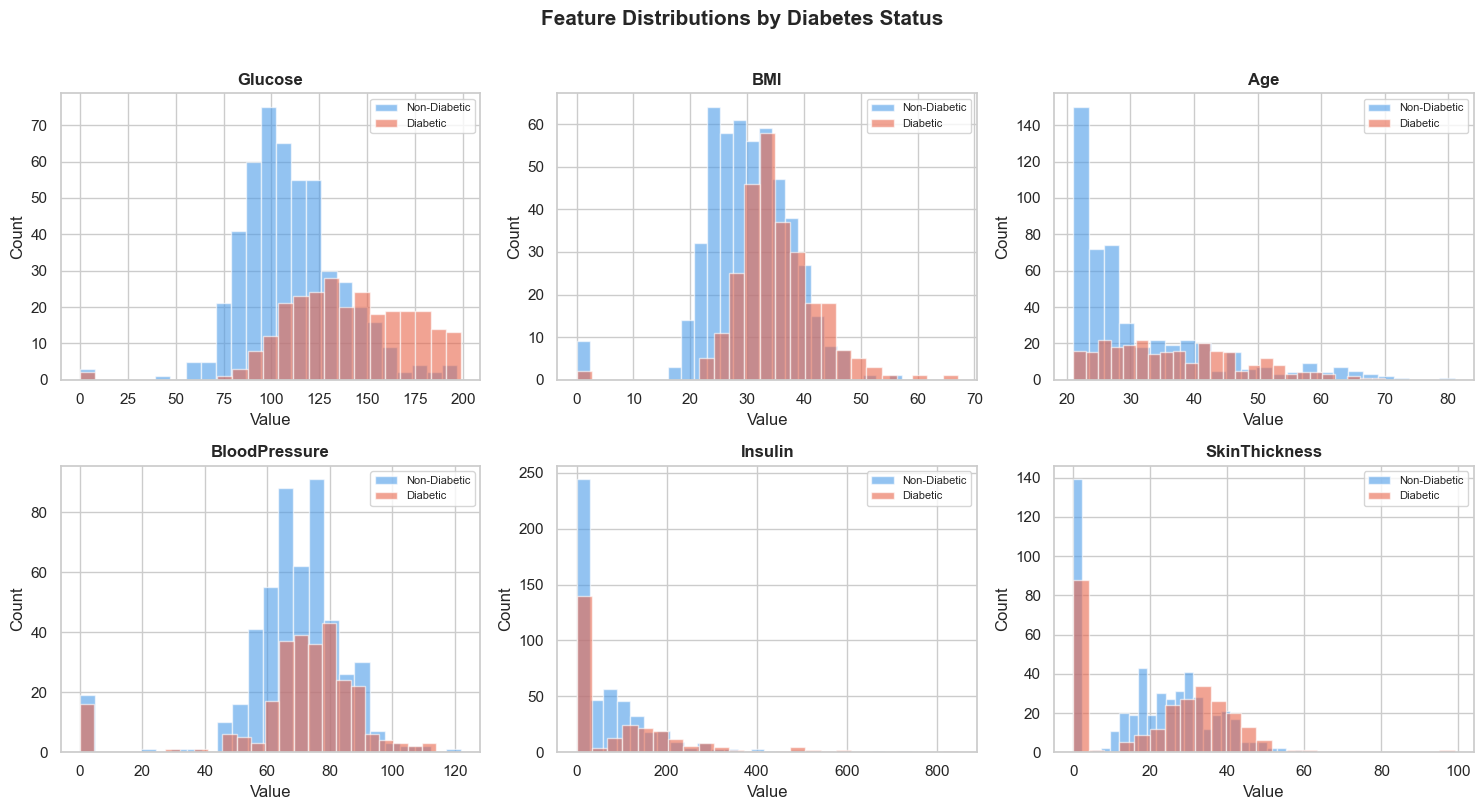

In [8]:
# Feature distributions split by outcome
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'SkinThickness']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for outcome, label, color in [(0, 'Non-Diabetic', '#4C9BE8'), (1, 'Diabetic', '#E8664C')]:
        subset = df[df['Outcome'] == outcome][feature]
        axes[i].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

fig.suptitle('Feature Distributions by Diabetes Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

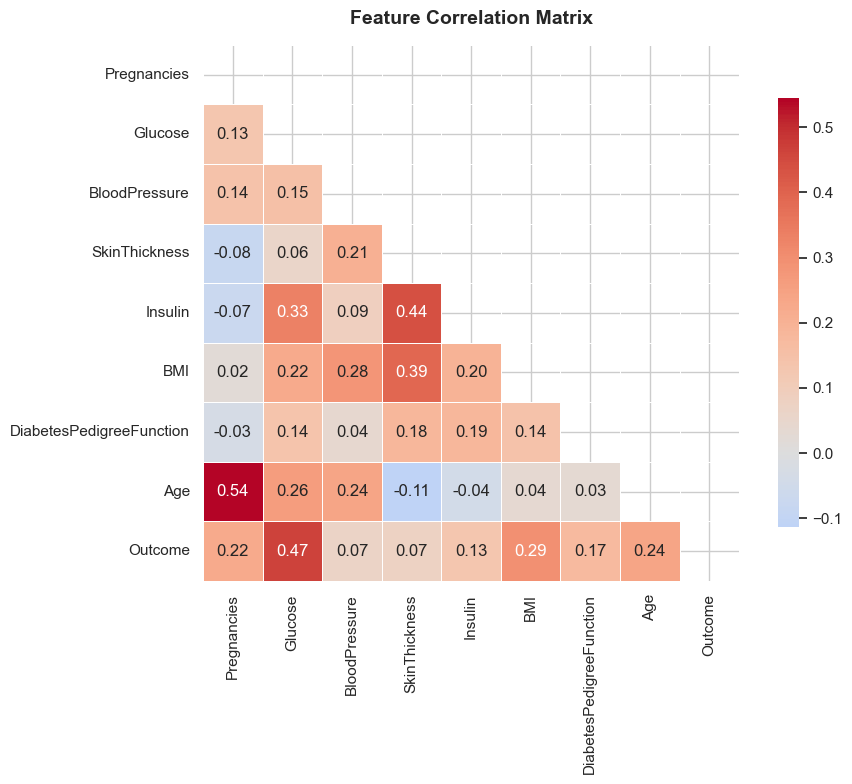

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

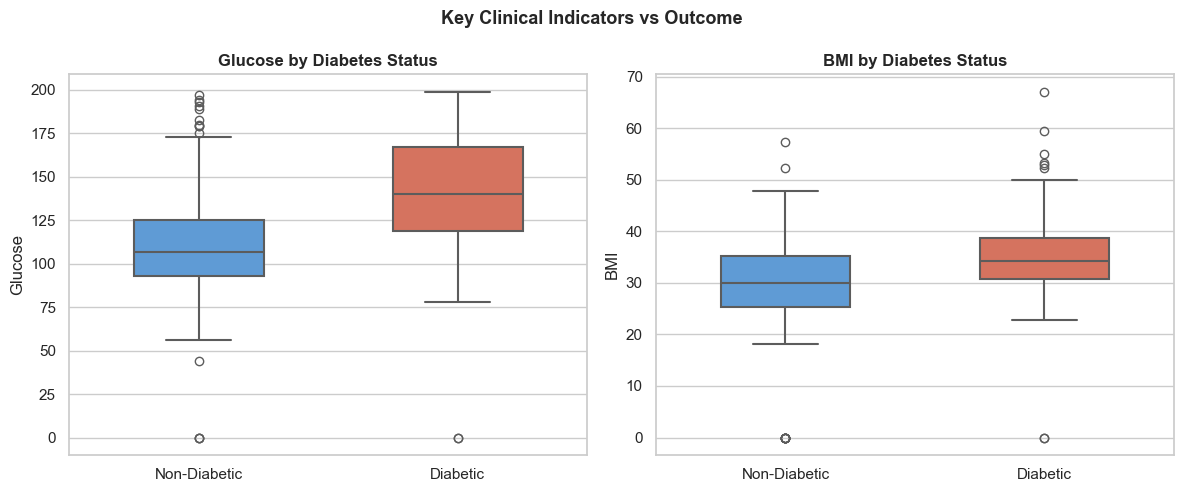

In [10]:
# Boxplots: Glucose and BMI by outcome
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, ['Glucose', 'BMI']):
    sns.boxplot(x='Outcome', y=feature, data=df, palette=['#4C9BE8', '#E8664C'],
                ax=ax, width=0.5, linewidth=1.5)
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
    ax.set_title(f'{feature} by Diabetes Status', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Key Clinical Indicators vs Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

We separate features from the target label, then apply **StandardScaler** to normalize all feature values. This is critical for SVM — since it relies on distance calculations, unscaled features can dominate the decision boundary.

In [11]:
# Separate features and target
features = df.drop(columns=['Outcome'])
target = df['Outcome']

print(f'Features shape: {features.shape}')
print(f'Target shape:   {target.shape}')

Features shape: (768, 8)
Target shape:   (768,)


In [12]:
# Apply StandardScaler to normalize all features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert back to DataFrame for readability
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

print('Scaled feature statistics (mean ≈ 0, std ≈ 1):')
features_scaled_df.describe().T[['mean', 'std']].round(4)

Scaled feature statistics (mean ≈ 0, std ≈ 1):


,mean,std
Pregnancies,-0.0,1.0007
Glucose,-0.0,1.0007
BloodPressure,0.0,1.0007
SkinThickness,0.0,1.0007
Insulin,-0.0,1.0007
BMI,0.0,1.0007
DiabetesPedigreeFunction,0.0,1.0007
Age,0.0,1.0007


## 5. Train / Test Split

We split the data into **80% training** and **20% test** sets. We use `stratify=target` to ensure both splits maintain the same class ratio as the original dataset — important when dealing with class imbalance.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target,
    test_size=0.2,
    stratify=target,
    random_state=2
)

print('Split Summary:')
print(f'  Total samples : {features_scaled.shape[0]}')
print(f'  Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/features_scaled.shape[0]*100:.0f}%)')
print(f'  Test set      : {X_test.shape[0]} samples ({X_test.shape[0]/features_scaled.shape[0]*100:.0f}%)')

Split Summary:
  Total samples : 768
  Training set  : 614 samples (80%)
  Test set      : 154 samples (20%)


## 6. Model Training

We use a **Support Vector Machine (SVM)** with a linear kernel. SVM finds the optimal hyperplane that maximizes the margin between the two classes — making it well-suited for binary medical classification tasks.

In [14]:
# Initialize and train the SVM classifier
svm_model = svm.SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

print('Model trained successfully.')
print(f'Support vectors per class: {svm_model.n_support_}')

Model trained successfully.
Support vectors per class: [157 157]


## 7. Model Evaluation

We evaluate the model on both the training set (to check for overfitting) and the test set (to measure real-world generalization).

In [15]:
# Predictions on train and test sets
train_predictions = svm_model.predict(X_train)
test_predictions  = svm_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy  = accuracy_score(y_test, test_predictions)

print('=== Model Accuracy ===')
print(f'  Training Set : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)')
print(f'  Test Set     : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

=== Model Accuracy ===
  Training Set : 0.7866 (78.66%)
  Test Set     : 0.7727 (77.27%)


In [16]:
# Detailed classification report
print('=== Classification Report (Test Set) ===')
print(classification_report(y_test, test_predictions, target_names=['Non-Diabetic', 'Diabetic']))

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.91      0.84       100
    Diabetic       0.76      0.52      0.62        54

    accuracy                           0.77       154
   macro avg       0.77      0.71      0.73       154
weighted avg       0.77      0.77      0.76       154



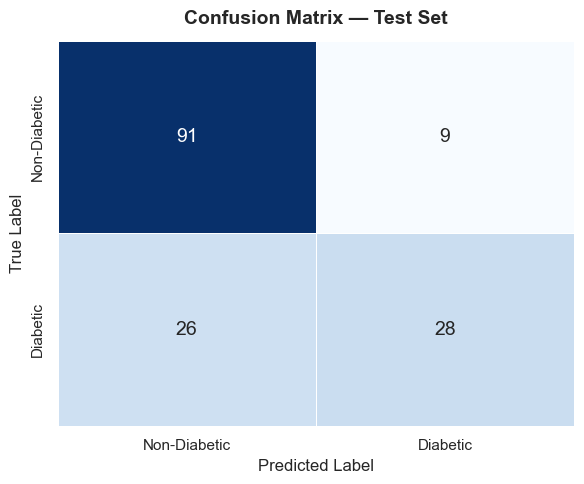

True Negatives  (correctly predicted Non-Diabetic): 91
False Positives (Non-Diabetic predicted as Diabetic): 9
False Negatives (Diabetic predicted as Non-Diabetic): 26
True Positives  (correctly predicted Diabetic): 28


In [17]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            cbar=False, ax=ax, annot_kws={'size': 14})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted Non-Diabetic): {tn}')
print(f'False Positives (Non-Diabetic predicted as Diabetic): {fp}')
print(f'False Negatives (Diabetic predicted as Non-Diabetic): {fn}')
print(f'True Positives  (correctly predicted Diabetic): {tp}')

## 8. Making Predictions on New Data

With the model trained, we can now make predictions on new, unseen patient data. The input must follow the same feature order as the training data and go through the same standardization step.

In [18]:
def predict_diabetes(patient_data: tuple) -> str:
    """
    Predict whether a patient is diabetic based on clinical measurements.

    Args:
        patient_data: tuple of (Pregnancies, Glucose, BloodPressure, SkinThickness,
                                Insulin, BMI, DiabetesPedigreeFunction, Age)

    Returns:
        str: Prediction result with confidence indicator
    """
    input_array = np.asarray(patient_data).reshape(1, -1)
    input_scaled = scaler.transform(input_array)
    prediction = svm_model.predict(input_scaled)[0]

    result = 'Diabetic' if prediction == 1 else 'Non-Diabetic'
    return f'Prediction: {result} (class {prediction})'


# Example patient: (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DPF, Age)
sample_patient = (5, 166, 72, 19, 175, 25.8, 0.587, 51)

print(f'Patient Input : {sample_patient}')
print(predict_diabetes(sample_patient))

Patient Input : (5, 166, 72, 19, 175, 25.8, 0.587, 51)
Prediction: Diabetic (class 1)


## 9. Save the Trained Model

We serialize the trained model using `pickle` so it can be reloaded and used in other applications (e.g., a Flask or Streamlit web app) without retraining.

In [19]:
import pickle

model_path = 'diabetes_prediction_model.pkl'

with open(model_path, 'wb') as model_file:
    pickle.dump(svm_model, model_file)

print(f'Model saved to "{model_path}"')

# Verify it loads correctly
with open(model_path, 'rb') as model_file:
    loaded_model = pickle.load(model_file)

verify_acc = accuracy_score(y_test, loaded_model.predict(X_test))
print(f'Loaded model test accuracy: {verify_acc*100:.2f}% ✓')

Model saved to "diabetes_prediction_model.pkl"
Loaded model test accuracy: 77.27% ✓
